# Tech Challenge Fase 4 — EDA e Feature Engineering (PETR4.SA)

Notebook exploratório para o modelo LSTM de previsão do preço de fechamento da Petrobras.

## Objetivos
1. Coletar histórico OHLCV via `yfinance`
2. Análise exploratória (tendência, sazonalidade, estacionariedade, autocorrelação)
3. Engenharia de features (indicadores técnicos)
4. Definição explícita do target e separação temporal (endereçando feedback da Fase 3)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from app.ml.data import download_history, temporal_split
from app.ml.features import FEATURE_COLUMNS, add_technical_indicators

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

## 1. Coleta de Dados

Histórico da PETR4.SA com `auto_adjust=True` para ajustar dividendos e splits (importante para evitar descontinuidades artificiais).

In [2]:
TICKER = 'PETR4.SA'
df = download_history(TICKER, start='2015-01-01')
print(f'Período: {df.index.min().date()} → {df.index.max().date()}')
print(f'Linhas: {len(df)}')
df.head()

Período: 2015-01-02 → 2026-05-20
Linhas: 2831


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,2.625715,2.625715,2.457501,2.460129,49559500
2015-01-05,2.402306,2.415448,2.241977,2.249862,78385100
2015-01-06,2.289287,2.320827,2.113188,2.176268,84723300
2015-01-07,2.249862,2.294543,2.197295,2.278774,85531000
2015-01-08,2.310313,2.468014,2.297171,2.425960,83306300


## 2. EDA: Tendência e Volatilidade

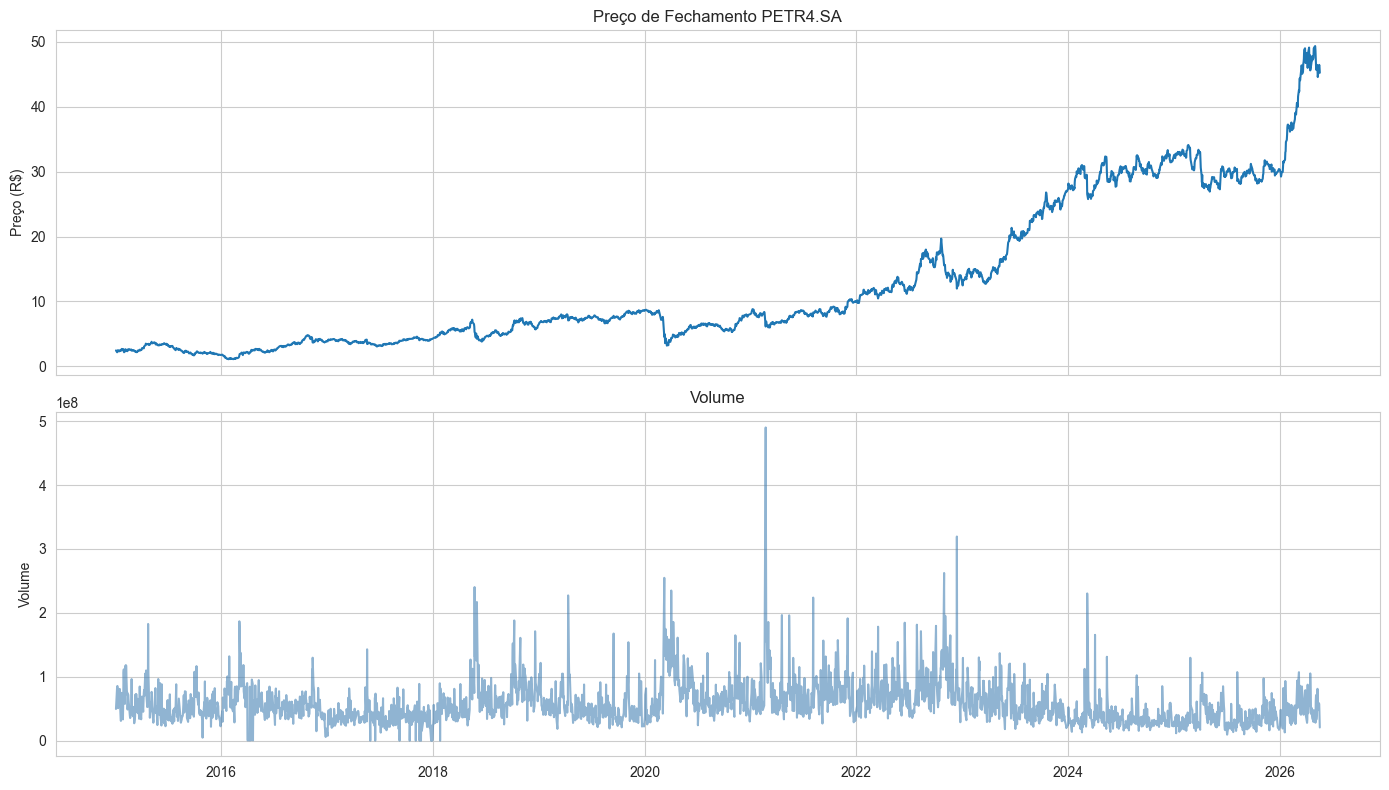

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df['Close'])
axes[0].set_title(f'Preço de Fechamento {TICKER}')
axes[0].set_ylabel('Preço (R$)')
axes[1].plot(df.index, df['Volume'], color='steelblue', alpha=0.6)
axes[1].set_title('Volume')
axes[1].set_ylabel('Volume')
plt.tight_layout()
plt.show()

Estatísticas dos retornos diários:
count    2830.000000
mean        0.001440
std         0.028464
min        -0.296978
25%        -0.011598
50%         0.001341
75%         0.015164
max         0.222222
Name: Close, dtype: float64


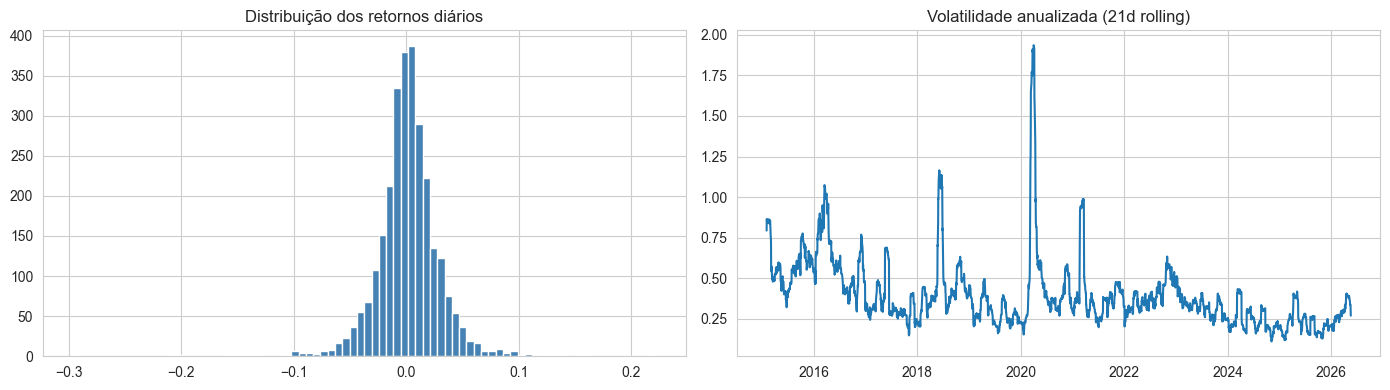

In [4]:
returns = df['Close'].pct_change().dropna()
print('Estatísticas dos retornos diários:')
print(returns.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(returns, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição dos retornos diários')
axes[1].plot(returns.rolling(21).std() * np.sqrt(252))
axes[1].set_title('Volatilidade anualizada (21d rolling)')
plt.tight_layout()
plt.show()

## 3. Estacionariedade (ADF Test)

Preços de ações típicamente não são estacionários (random walk), mas os retornos são. Validar isso reforça a escolha de usar tanto o preço quanto retornos como features.

In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f'{name}: ADF stat={result[0]:.4f} | p-value={result[1]:.4f} | estacionária={result[1] < 0.05}')

adf_report(df['Close'], 'Close')
adf_report(df['Close'].pct_change(), 'Retornos')

Close: ADF stat=1.4953 | p-value=0.9975 | estacionária=False
Retornos: ADF stat=-18.2548 | p-value=0.0000 | estacionária=True


## 4. Feature Engineering

Indicadores técnicos usados como features (endereça o feedback da Fase 3 sobre feature engineering mais avançado):

| Feature | Tipo | Capta |
|---------|------|-------|
| SMA_7, SMA_21 | Tendência | Média móvel simples curta/longa |
| EMA_12, EMA_26 | Tendência | Média móvel exponencial (mais sensível) |
| RSI_14 | Momentum | Força relativa (sobrecompra/sobrevenda) |
| MACD, MACD_Signal | Momentum | Convergence/divergence das EMAs |
| BB_Upper, BB_Lower | Volatilidade | Bandas de Bollinger (2 desvios) |
| Volatility_10 | Volatilidade | Desvio padrão dos retornos em 10 dias |
| Return_1d | Momentum | Retorno do dia anterior |

In [6]:
enriched = add_technical_indicators(df)
print(f'Linhas após features: {len(enriched)} (perda esperada por warmup de indicadores)')
print(f'Features: {FEATURE_COLUMNS}')
enriched[FEATURE_COLUMNS].tail()

Linhas após features: 2811 (perda esperada por warmup de indicadores)
Features: ['Close', 'Volume', 'Return_1d', 'SMA_7', 'SMA_21', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'Volatility_10']


Price,Close,Volume,Return_1d,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,Volatility_10
Date,,,,,,,,,,,,,
2026-05-14,45.000000,47760000,0.009648,45.834286,47.006068,46.371832,46.549648,35.436389,-0.177816,0.322747,49.732297,44.257000,0.015669
2026-05-15,45.470001,59380500,0.010444,45.577143,46.922046,46.233089,46.469674,40.981871,-0.236585,0.210881,49.759409,44.151108,0.016461
2026-05-18,46.439999,57388200,0.021333,45.608571,46.930722,46.264921,46.467476,45.409675,-0.202555,0.128194,49.655527,44.106489,0.018500
2026-05-19,46.090000,40943000,-0.007537,45.668571,46.843341,46.238010,46.439515,43.078412,-0.201504,0.062254,49.640614,44.170718,0.018308
2026-05-20,45.230000,20593600,-0.018659,45.497143,46.825873,46.082932,46.349921,30.871805,-0.266989,-0.003595,49.676319,44.019409,0.017138


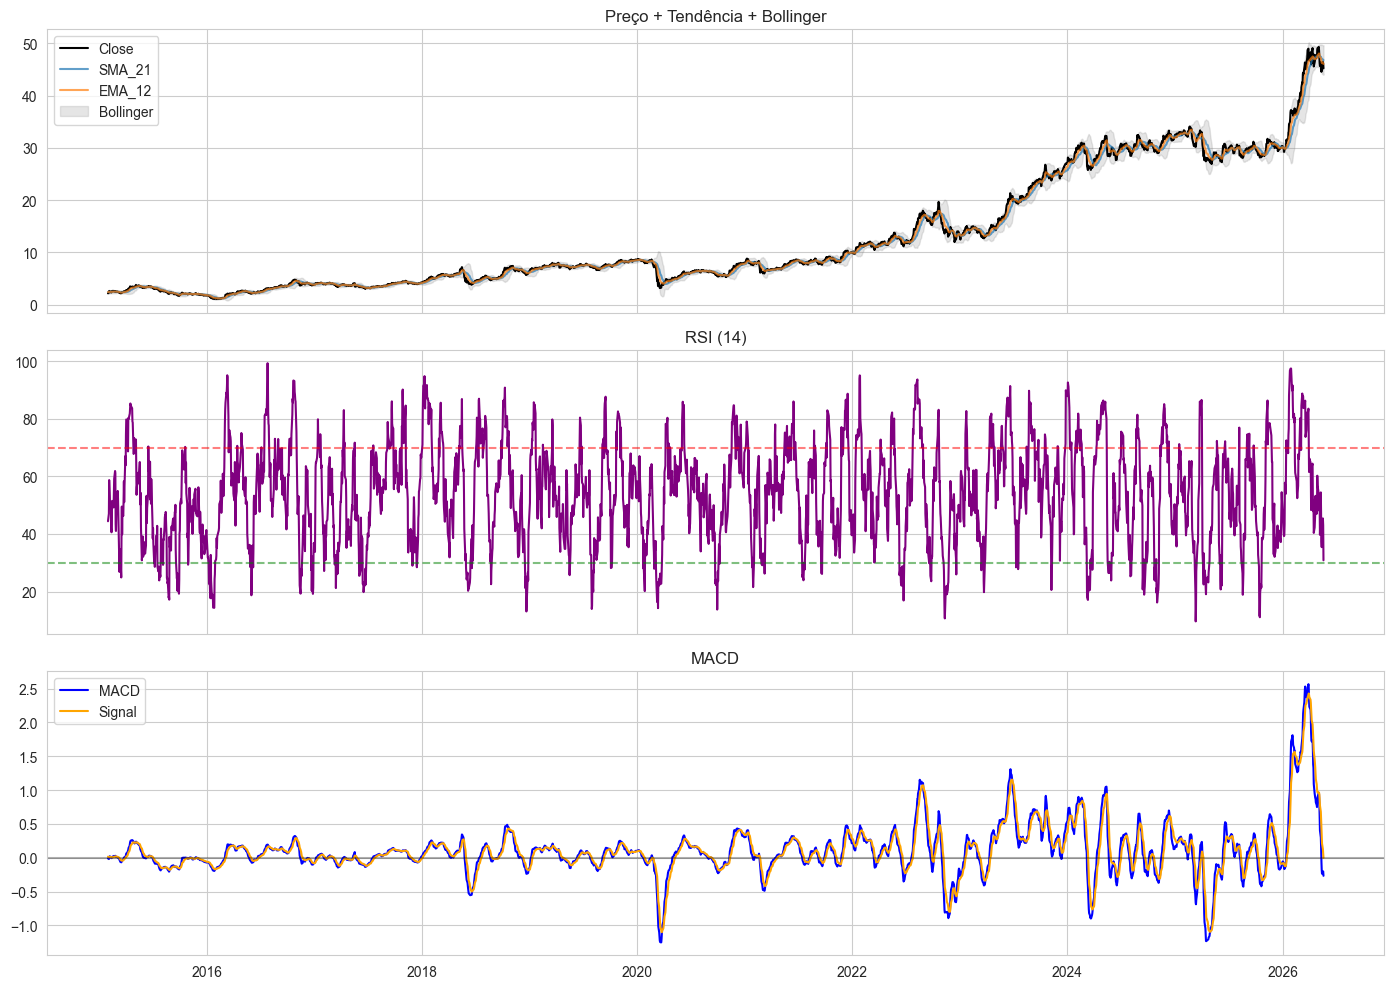

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(enriched.index, enriched['Close'], label='Close', color='black')
axes[0].plot(enriched.index, enriched['SMA_21'], label='SMA_21', alpha=0.7)
axes[0].plot(enriched.index, enriched['EMA_12'], label='EMA_12', alpha=0.7)
axes[0].fill_between(enriched.index, enriched['BB_Lower'], enriched['BB_Upper'], alpha=0.2, color='gray', label='Bollinger')
axes[0].legend()
axes[0].set_title('Preço + Tendência + Bollinger')

axes[1].plot(enriched.index, enriched['RSI_14'], color='purple')
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('RSI (14)')

axes[2].plot(enriched.index, enriched['MACD'], label='MACD', color='blue')
axes[2].plot(enriched.index, enriched['MACD_Signal'], label='Signal', color='orange')
axes[2].axhline(0, color='black', alpha=0.3)
axes[2].legend()
axes[2].set_title('MACD')

plt.tight_layout()
plt.show()

## 5. Correlação entre Features

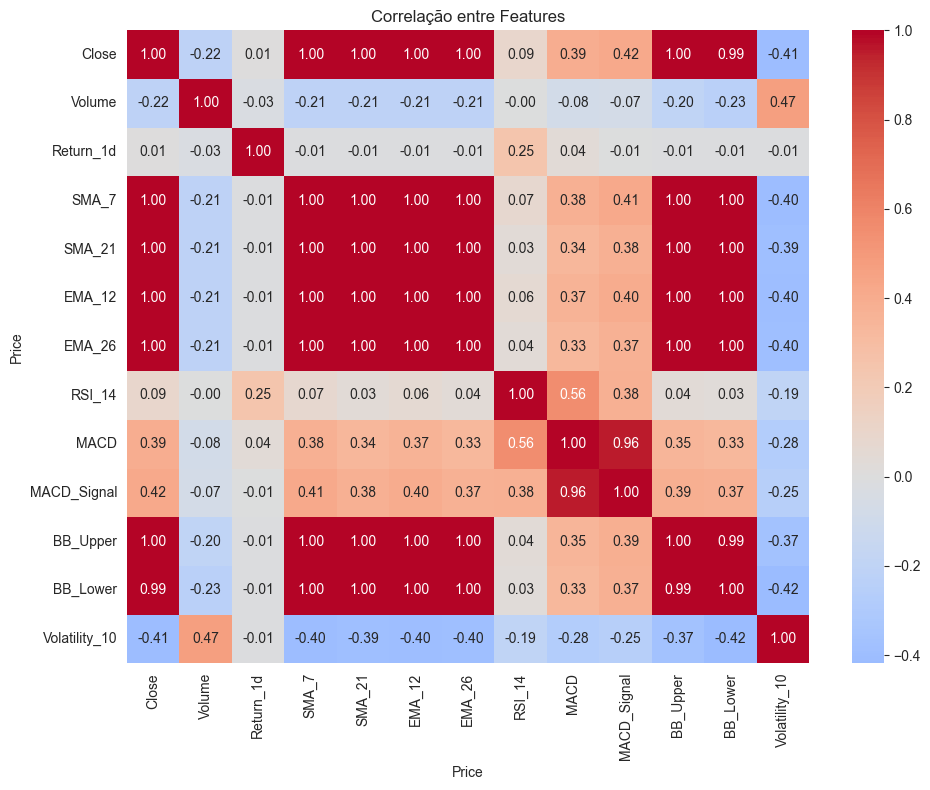

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(enriched[FEATURE_COLUMNS].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlação entre Features')
plt.tight_layout()
plt.show()

## 6. Target e Separação Temporal (Feedback Fase 3)

**Target definido explicitamente:** `y_t = Close_{t+1}` — o preço de fechamento do próximo dia útil.

**Janela de entrada:** 60 dias de histórico de todas as 13 features.

**Split temporal estrito** (sem vazamento): 70% treino → 15% validação → 15% teste.

Treino: 2015-01-30 → 2022-12-28 (1967 linhas)
Validação: 2022-12-29 → 2024-09-05 (422 linhas)
Teste: 2024-09-06 → 2026-05-20 (422 linhas)


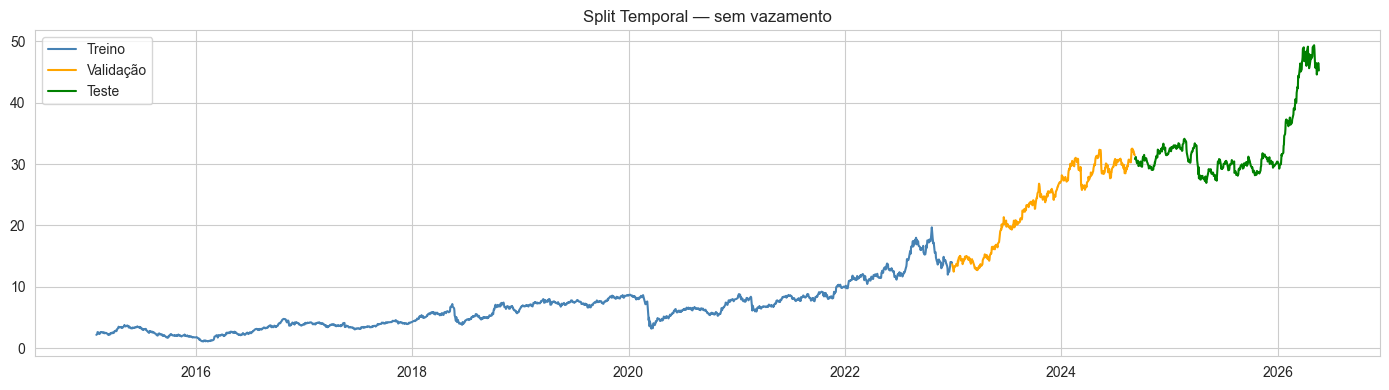

In [9]:
split = temporal_split(enriched, train_ratio=0.7, val_ratio=0.15)
print(f'Treino: {split.train.index.min().date()} → {split.train.index.max().date()} ({len(split.train)} linhas)')
print(f'Validação: {split.val.index.min().date()} → {split.val.index.max().date()} ({len(split.val)} linhas)')
print(f'Teste: {split.test.index.min().date()} → {split.test.index.max().date()} ({len(split.test)} linhas)')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(split.train.index, split.train['Close'], label='Treino', color='steelblue')
ax.plot(split.val.index, split.val['Close'], label='Validação', color='orange')
ax.plot(split.test.index, split.test['Close'], label='Teste', color='green')
ax.legend()
ax.set_title('Split Temporal — sem vazamento')
plt.tight_layout()
plt.show()

## 7. Próximos passos

Executar o treinamento do LSTM:

```bash
python -m ml_training.train --ticker PETR4.SA --epochs 50 --sequence-length 60
```

Saídas em `models/`:
- `lstm_petr4.keras` — modelo treinado
- `scaler_petr4.joblib` — MinMaxScaler ajustado apenas no treino
- `meta_petr4.json` — metadados (métricas, features, sequência)